# 🧠 Phân nhóm Khách hàng Thông minh (Customer Segmentation)
## Sử dụng K-Means Clustering trên dữ liệu RFM

**Mục tiêu:** Tự động phân nhóm khách hàng dựa trên hành vi mua sắm (Recency, Frequency, Monetary) bằng thuật toán học không giám sát K-Means.

**Nguồn dữ liệu:** Kết nối trực tiếp vào Database `ECommerceDB` trên SQL Server (đã xây dựng ở Phase 1).


# **1. Import thư viện và kết nối SQL Server**


In [1]:
# Nạp thư viện
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Kết nối Python với SQL Server (Windows Authentication)
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=.;'
    'DATABASE=ECommerceDB;'
    'Trusted_Connection=yes;'
)

# Kiểm tra kết nối
df_test = pd.read_sql("SELECT TOP 5 * FROM Orders", conn)
print(f"Kết nối thành công | Số cột: {df_test.shape[1]} | Số dòng: {df_test.shape[0]}")
df_test.head()


Kết nối thành công | Số cột: 13 | Số dòng: 5


,Order_Id,Order_Date,Order_Time,Aging,Customer_Id,Product_Id,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,1,2018-01-02,10:56:33,8.0,37077,11,140.0,1,0.3,46.0,4.6,Medium,credit_card
1,2,2018-07-24,20:41:37,2.0,59173,40,211.0,1,0.3,112.0,11.2,Medium,credit_card
2,3,2018-11-08,08:38:49,8.0,41066,22,117.0,5,0.1,31.2,3.1,Critical,credit_card
3,4,2018-04-18,19:28:06,7.0,50741,37,118.0,1,0.3,26.2,2.6,High,credit_card
4,5,2018-08-13,21:18:39,9.0,53639,12,250.0,1,0.3,160.0,16.0,Critical,credit_card


# **2. Trích xuất dữ liệu RFM từ SQL Server**


Mô hình RFM đánh giá hành vi khách hàng dựa trên 3 chỉ số:
- **Recency (R):** Lần mua gần nhất cách đây bao nhiêu ngày? (Càng thấp càng tốt)
- **Frequency (F):** Tổng số đơn hàng đã đặt? (Càng cao càng tốt)
- **Monetary (M):** Tổng tiền đã chi tiêu? (Càng cao càng tốt)

In [3]:
# Truy vấn SQL: Tính RFM cho từng khách hàng
query_rfm = """
WITH ReferenceDate AS (
    SELECT MAX(Order_Date) AS max_date FROM Orders
)
SELECT
    o.Customer_Id,
    c.Gender,
    DATEDIFF(DAY, MAX(o.Order_Date), rd.max_date) AS Recency,
    COUNT(o.Order_Id) AS Frequency,
    ROUND(SUM(o.Sales), 2) AS Monetary,
    ROUND(AVG(o.Discount), 2) AS Avg_Discount,
    ROUND(AVG(o.Profit), 2) AS Avg_Profit
FROM Orders o
JOIN Customers c ON o.Customer_Id = c.Customer_Id
CROSS JOIN ReferenceDate rd
GROUP BY o.Customer_Id, c.Gender, rd.max_date
"""

df_rfm = pd.read_sql(query_rfm, conn)
print(f"So khach hang: {df_rfm.shape[0]} | So features: {df_rfm.shape[1]}")
df_rfm.head(10)


So khach hang: 38997 | So features: 7


,Customer_Id,Gender,Recency,Frequency,Monetary,Avg_Discount,Avg_Profit
0,39794,Male,127,1,218.0,0.40,94.40
1,96568,Female,148,1,34.0,0.30,11.30
2,49635,Male,260,2,187.0,0.30,26.95
3,52506,Male,351,1,159.0,0.50,63.10
4,35526,Female,280,1,224.0,0.40,135.00
5,15675,Male,184,1,111.0,0.20,17.70
6,32655,Male,211,1,85.0,0.20,3.30
7,75320,Female,234,2,296.0,0.30,68.90
8,54072,Male,125,2,341.0,0.20,82.05
9,88032,Male,11,3,269.0,0.27,41.83


In [4]:
# Kiểm tra thống kê tổng quan của bộ dữ liệu RFM
df_rfm.describe().round(2)


,Customer_Id,Recency,Frequency,Monetary,Avg_Discount,Avg_Profit
count,38997.00,38997.00,38997.00,38996.00,38996.00,38997.00
mean,57249.79,143.12,1.32,200.36,0.30,70.53
std,26085.36,96.35,0.58,116.62,0.12,45.39
min,10000.00,0.00,1.00,33.00,0.10,0.50
25%,34784.00,58.00,1.00,117.00,0.20,28.25
50%,59330.00,133.00,1.00,207.00,0.30,66.30
75%,79894.00,221.00,2.00,245.00,0.40,112.10
max,99999.00,363.00,6.00,994.00,0.50,167.50


In [5]:
# Kiểm tra dữ liệu thiếu (Missing Values)
df_rfm.isnull().sum()


Customer_Id     0
Gender          0
Recency         0
Frequency       0
Monetary        1
Avg_Discount    1
Avg_Profit      0
dtype: int64

# **3. Tiền xử lý dữ liệu (Preprocessing)**

Xử lý giá trị thiếu, loại bỏ cột không dùng cho mô hình, và chuẩn hóa dữ liệu bằng StandardScaler (bắt buộc cho K-Means vì thuật toán nhạy cảm với thang đo).

In [6]:
# Xóa dòng có giá trị thiếu (chỉ 1 dòng)
df_rfm = df_rfm.dropna()
print(f"Sau khi xoa missing: {df_rfm.shape[0]} khach hang")

Sau khi xoa missing: 38995 khach hang


In [7]:
# Tách các cột số dùng cho mô hình (bỏ Customer_Id và Gender)
features = ['Recency', 'Frequency', 'Monetary', 'Avg_Discount', 'Avg_Profit']
X = df_rfm[features]

In [8]:
# Chuẩn hóa dữ liệu về cùng thang đo (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Shape du lieu sau chuan hoa: {X_scaled.shape}")
pd.DataFrame(X_scaled, columns=features).describe().round(2)

Shape du lieu sau chuan hoa: (38995, 5)


,Recency,Frequency,Monetary,Avg_Discount,Avg_Profit
count,38995.00,38995.00,38995.00,38995.00,38995.00
mean,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.49,-0.54,-1.44,-1.67,-1.54
25%,-0.88,-0.54,-0.71,-0.85,-0.93
50%,-0.11,-0.54,0.06,-0.03,-0.09
75%,0.81,1.17,0.38,0.78,0.92
max,2.28,8.02,6.81,1.60,2.14


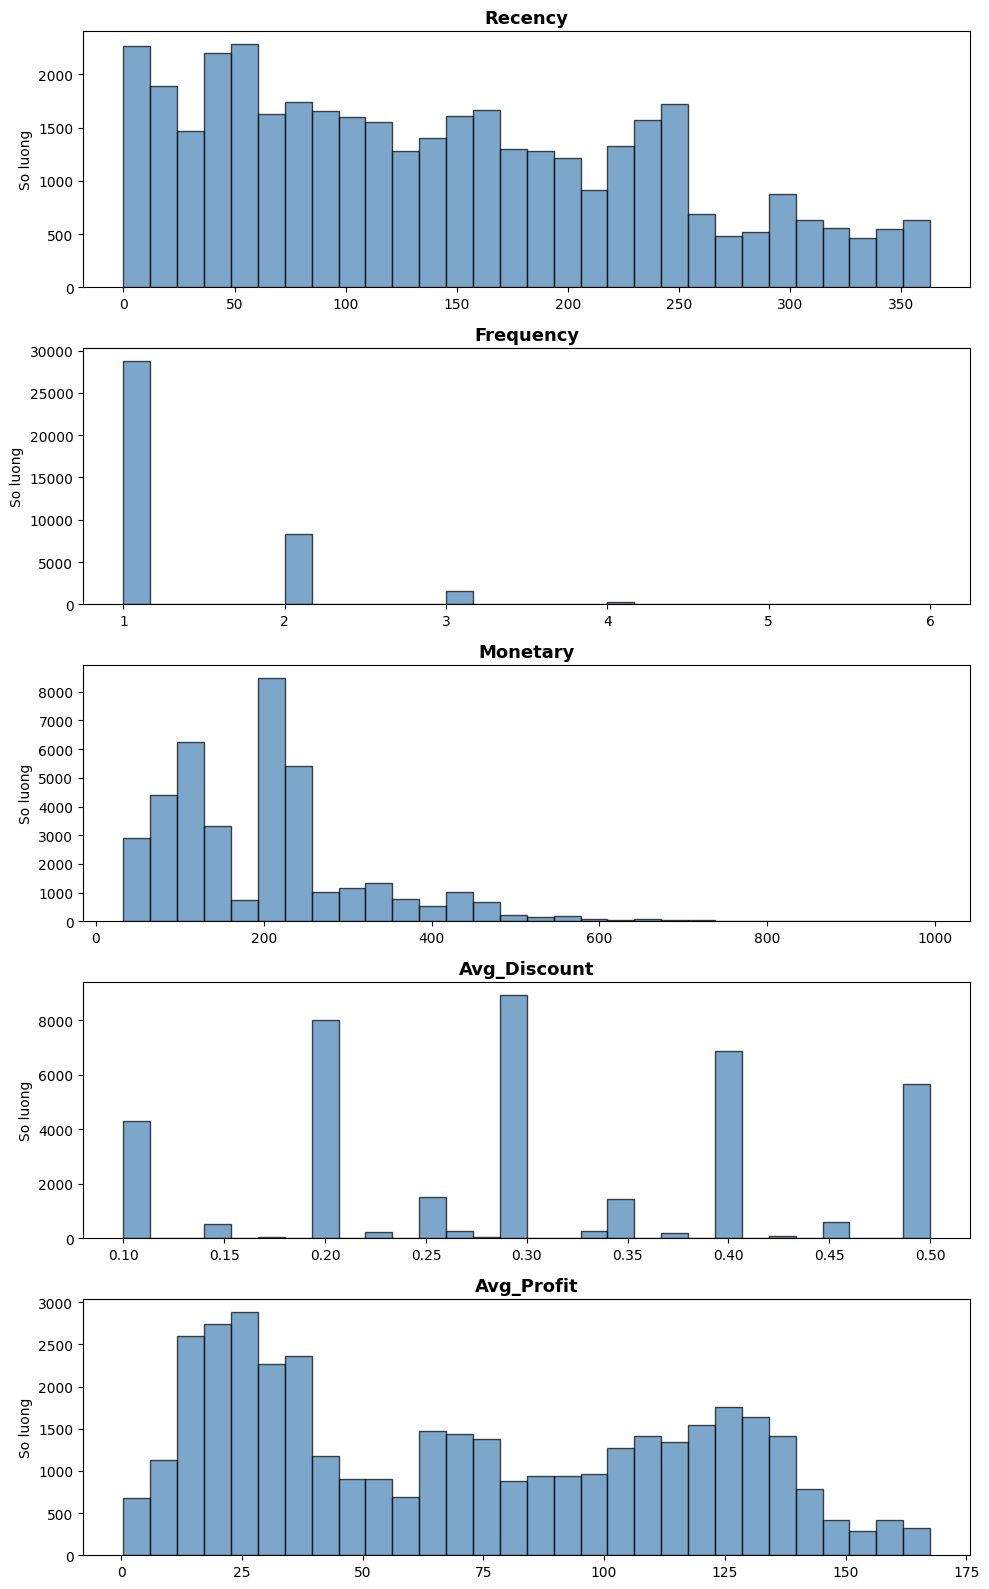

In [9]:
# Trực quan hóa phân phối từng feature
fig, axes = plt.subplots(5, 1, figsize=(10, 16))
for i, col in enumerate(features):
    axes[i].hist(df_rfm[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('So luong')
plt.tight_layout()
plt.show()


**Nhận xét phân phối dữ liệu:**
- **Recency (Số ngày kể từ lần mua cuối):** Phân bố khá đều (0-363 ngày), không bị lệch nghiêm trọng.
- **Frequency (Tổng số đơn hàng):** Lệch phải rất mạnh. Phần lớn khách hàng chỉ mua 1 lần duy nhất (75% khách mua <= 2 lần). Đây là đặc trưng điển hình của dữ liệu E-commerce.
- **Monetary (Tổng tiền chi tiêu):** Lệch phải. Đa số khách chi tiêu dưới 300 USD, một số ít chi tiêu lên đến gần 1,000 USD.
- **Avg_Discount (Mức giảm giá trung bình):** Phân bố rời rạc theo 5 mức (0.1 - 0.5), không liên tục.
- **Avg_Profit (Lợi nhuận trung bình mỗi đơn):** Tập trung ở vùng thấp (0-50 USD), một số ít khách tạo lợi nhuận cao hơn.

Dữ liệu đã được chuẩn hóa (StandardScaler) với mean=0 và std=1, sẵn sàng đưa vào thuật toán K-Means.


# **4. Huấn luyện mô hình K-Means**

Sử dụng 2 phương pháp để xác định số cụm (K) tối ưu:
- **Elbow Method:** Tìm điểm "khuỷu tay" trên đồ thị Inertia, nơi việc tăng K không còn giảm đáng kể sai số.
- **Silhouette Score:** Đo mức độ tách biệt giữa các cụm, điểm càng cao (gần 1) càng tốt.

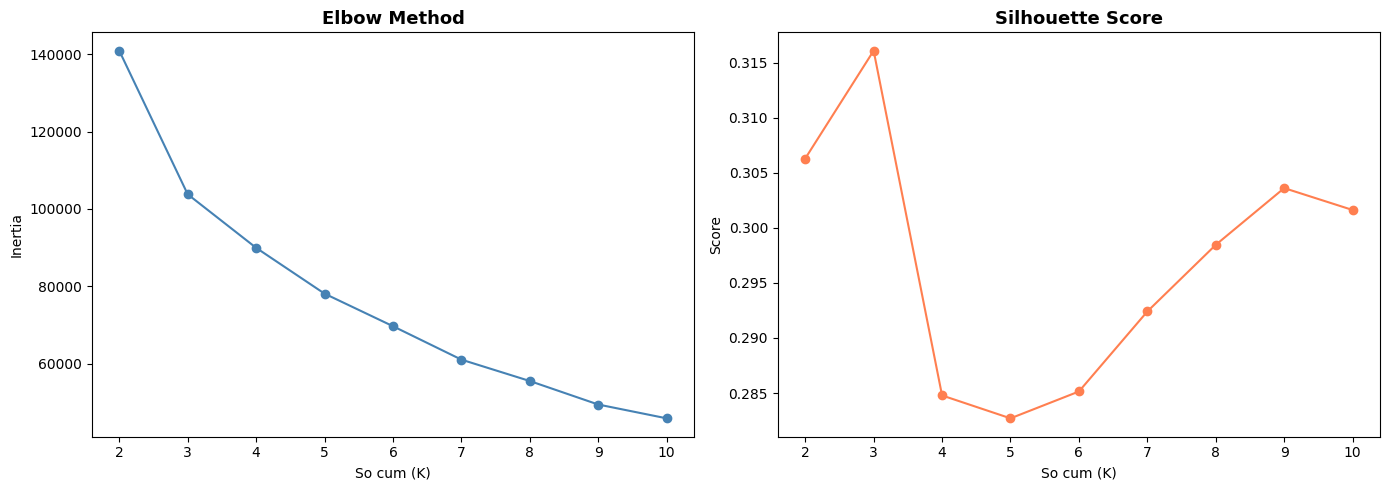

In [10]:
# Elbow Method: Thử K từ 2 đến 10
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Ve bieu do Elbow va Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('So cum (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('So cum (K)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()


* Nhật xét:
    * Elbow Method: Điểm khuỷu tay nằm ở K=3 (sau đó đường cong giảm chậm lại).
    * Silhouette Score: K=3 đạt điểm cao nhất (~0.315), vượt trội so với các giá trị K khác
* Kết luận:
    * K=3 là lựa chọn tối ưu. Và trùng khớp hoàn hảo với 3 nhóm khách hàng VIP, Săn sale, Lướt sóng.

In [11]:
# Train mo hinh K-Means voi K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Dem so luong khach hang trong tung cum
print("So luong khach hang theo tung cum:")
print(df_rfm['Cluster'].value_counts().sort_index())


So luong khach hang theo tung cum:
Cluster
0    12864
1    17135
2     8996
Name: count, dtype: int64


# **5. Phân tích và đặt tên từng cụm khách hàng (Cluster Profiling)**

So sánh giá trị trung bình của các chỉ số RFM giữa 3 cụm để hiểu đặc điểm hành vi mua sắm và đặt tên chiến lược cho từng nhóm.

In [12]:
# Tinh gia tri trung binh cua tung cum
cluster_profile = df_rfm.groupby('Cluster')[features].mean().round(2)
cluster_profile


,Recency,Frequency,Monetary,Avg_Discount,Avg_Profit
Cluster,,,,,
0,158.22,1.00,220.29,0.32,120.80
1,158.58,1.07,102.75,0.29,29.95
2,92.10,2.24,357.79,0.30,75.94


**Nhận xét:**
- Cụm 0 và 1 có Recency (số ngày kể từ lần mua cuối) gần bằng nhau (~158 ngày), nhưng khác biệt lớn ở Monetary (tổng chi tiêu): 220 vs 102 USD và Avg_Profit (lợi nhuận trung bình): 120 vs 29 USD.
- Cụm 2 nổi bật với Recency (số ngày kể từ lần mua cuối) thấp nhất (92 ngày — mua gần đây nhất), Frequency (tần suất mua) cao nhất (2.24 lần) và Monetary (tổng chi tiêu) cao nhất (357 USD), cho thấy đây là nhóm khách hàng tích cực nhất.
- Avg_Discount (mức giảm giá trung bình) giữa 3 cụm chênh lệch không đáng kể (0.29 - 0.32), cho thấy mức giảm giá không phải yếu tố phân biệt chính giữa các nhóm.


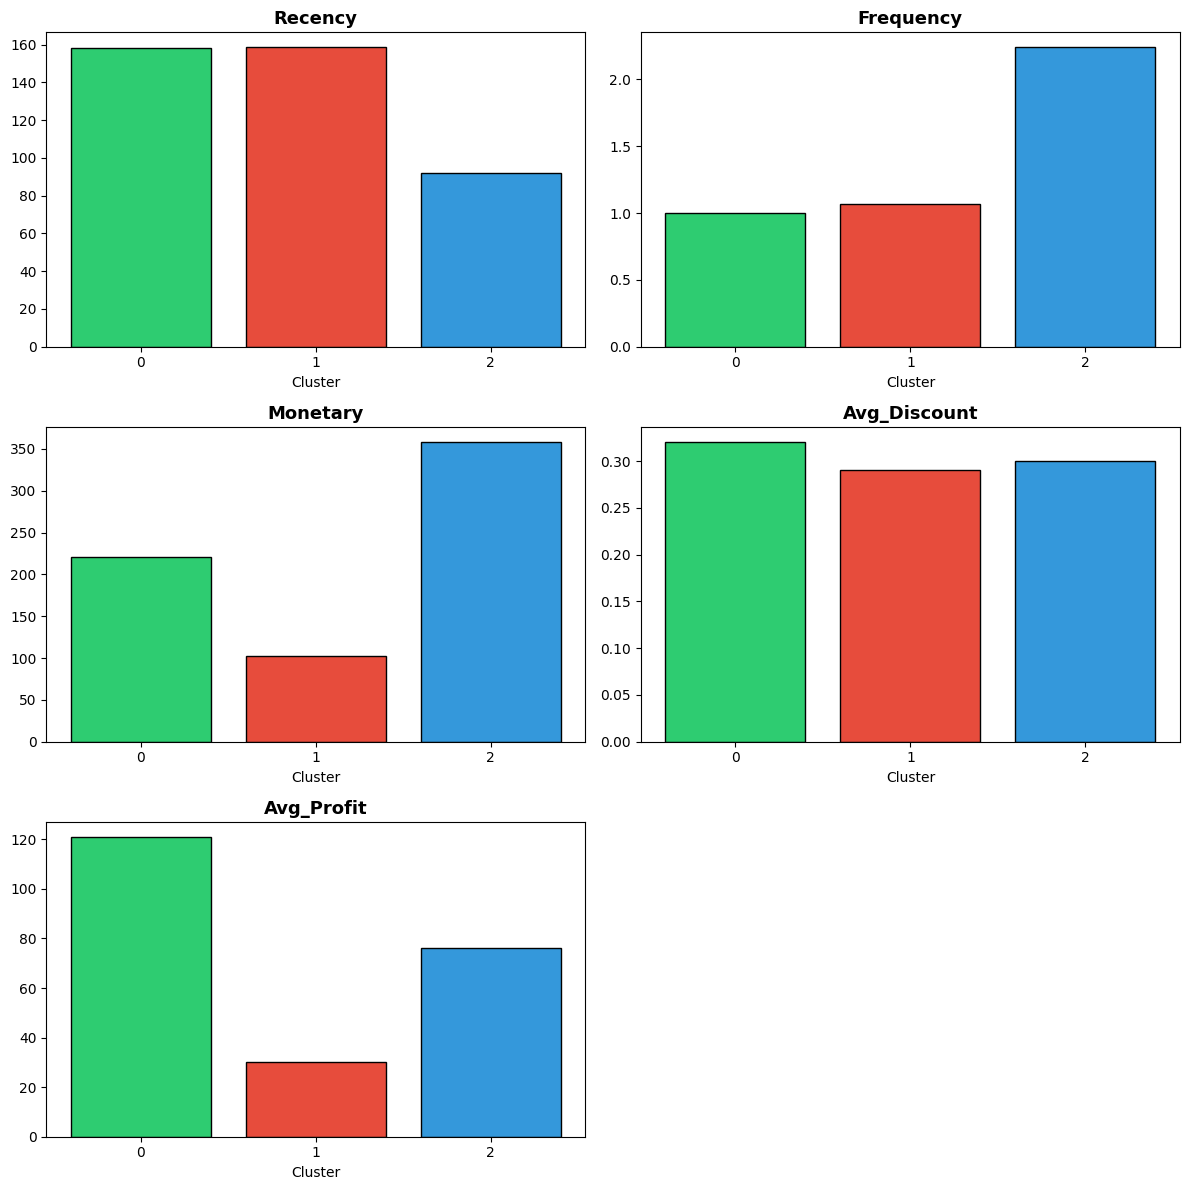

In [16]:
# Truc quan hoa so sanh cac cum 
colors = ['#2ecc71', '#e74c3c', '#3498db']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].bar(cluster_profile.index, cluster_profile[col], color=colors, edgecolor='black')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticks([0, 1, 2])

axes[5].axis('off')  # O thu 6 bo trong
plt.tight_layout()
plt.show()


**Nhận xét biểu đồ:**
- **Recency:** Cụm 2 (xanh dương) có cột thấp nhất (~92 ngày), nghĩa là nhóm này mua hàng gần đây nhất. Cụm 0 và 1 gần bằng nhau (~158 ngày).
- **Frequency:** Cụm 2 vượt trội rõ rệt (2.24 lần), trong khi Cụm 0 và 1 gần như chỉ mua 1 lần duy nhất.
- **Monetary:** Cụm 2 dẫn đầu (357 USD), gấp 3.5 lần so với Cụm 1 (102 USD). Cụm 0 ở mức trung bình (220 USD).
- **Avg_Discount:** Cả 3 cụm có mức giảm giá gần như bằng nhau (0.29 - 0.32), biểu đồ cho thấy discount không tạo ra sự khác biệt giữa các nhóm.
- **Avg_Profit:** Cụm 0 tạo lợi nhuận cao nhất mỗi đơn (120 USD), gấp 4 lần Cụm 1 (29 USD). Đây là điểm đáng chú ý: Cụm 0 mua ít nhưng mỗi đơn rất "chất lượng".


In [14]:
# Dem ti le gioi tinh trong tung cum
gender_dist = df_rfm.groupby(['Cluster', 'Gender']).size().unstack(fill_value=0)
print("Phan bo gioi tinh theo tung cum:")
print(gender_dist)


Phan bo gioi tinh theo tung cum:
Gender   Female  Male
Cluster              
0          5572  7292
1          7437  9698
2          1890  7106


**Nhận xét phân bố giới tính:**
- Cụm 0 và 1 có tỉ lệ giới tính tương đương nhau: khoảng 57% Nam và 43% Nữ.
- Cụm 2 (VIP) có sự chênh lệch rất lớn: 79% Nam và chỉ 21% Nữ. Điều này gợi ý rằng khách hàng trung thành, mua sắm thường xuyên và chi tiêu cao trong dataset này chủ yếu là Nam giới.
- Insight cho Marketing: Các chương trình loyalty và ưu đãi VIP nên được thiết kế hướng đến đối tượng Nam giới để tối ưu tỉ lệ chuyển đổi.


**Tổng kết phân nhóm khách hàng:**

| Cụm | Tên gọi | Số lượng | Đặc điểm chính |
|---|---|---|---|
| 0 | Premium One-Time (Mua ít nhưng giá trị cao) | 12,864 (33%) | Mua 1 lần, lợi nhuận cao nhất (120 USD/đơn), sẵn sàng chi trả giá cao |
| 1 | Low-Value (Giá trị thấp) | 17,135 (44%) | Nhóm đông nhất, chi tiêu thấp (102 USD), lợi nhuận thấp, nguy cơ rời bỏ cao |
| 2 | VIP Loyal (Trung thành cao cấp) | 8,996 (23%) | Mua gần đây nhất, tần suất cao nhất, chi tiêu lớn nhất, 79% là Nam giới |


# **6. Trực quan hóa 3D Scatter Plot**

* Biểu đồ phân tán 3 chiều thể hiện sự phân bố của 3 cụm khách hàng theo 3 trục:
    * Recency (số ngày kể từ lần mua cuối)
    * Frequency (tần suất mua)
    * Monetary (tổng chi tiêu)

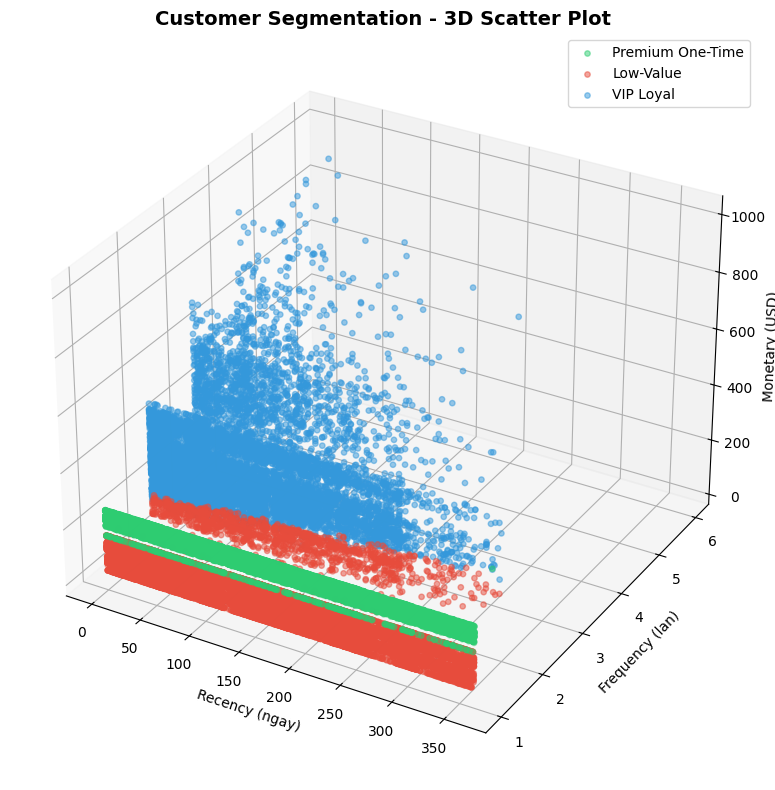

In [23]:
# Bieu do 3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors_map = {0: '#2ecc71', 1: '#e74c3c', 2: '#3498db'}
labels_map = {0: 'Premium One-Time', 1: 'Low-Value', 2: 'VIP Loyal'}

for cluster in [0, 1, 2]:
    mask = df_rfm['Cluster'] == cluster
    ax.scatter(
        df_rfm[mask]['Recency'],
        df_rfm[mask]['Frequency'],
        df_rfm[mask]['Monetary'],
        c=colors_map[cluster],
        label=labels_map[cluster],
        alpha=0.5,
        s=15
    )

ax.set_xlabel('Recency (ngay)')
ax.set_ylabel('Frequency (lan)')
ax.set_zlabel('Monetary (USD)')
ax.set_title('Customer Segmentation - 3D Scatter Plot', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


**Nhận xét:**
- Cụm VIP Loyal (xanh dương) phân bố rõ ràng ở vùng Recency thấp, Frequency cao và Monetary cao, tách biệt hẳn so với 2 cụm còn lại.
- Cụm Premium One-Time (xanh lá) và Low-Value (đỏ) đều tập trung ở Frequency = 1, nhưng khác nhau rõ ở trục Monetary: xanh lá nằm cao hơn đỏ.
- Biểu đồ cho thấy Frequency là yếu tố phân tách mạnh nhất giữa nhóm VIP và 2 nhóm còn lại.


# **7. Kết luận**
Mô hình K-Means (K=3) đã phân nhóm thành công 38,995 khách hàng thành 3 phân khúc có đặc điểm hành vi rõ ràng:

| Cụm | Tên gọi | Tỉ lệ | Đặc điểm |
|---|---|---|---|
| 0 | Premium One-Time | 33% | Mua 1 lần, lợi nhuận cao (120 USD/đơn) |
| 1 | Low-Value | 44% | Mua 1 lần, chi tiêu thấp, nguy cơ rời bỏ cao |
| 2 | VIP Loyal | 23% | Mua thường xuyên, chi tiêu lớn, 79% Nam giới |

**Đề xuất chiến lược Marketing:**
- **VIP Loyal:** Triển khai chương trình loyalty, ưu đãi độc quyền để giữ chân.
- **Premium One-Time:** Gửi email/SMS nhắc nhở mua lại, cross-sell sản phẩm liên quan.
- **Low-Value:** Chiến dịch retargeting với voucher giảm giá để kích hoạt lại.
